Exploratory Data Analysis with my Fresh (4/29/26) EEOC1 Tables

In [16]:
import pandas as pd
import dtale
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path

In [19]:
data_dir = Path('../EEOC_Data/EEOC1_Cleaned_Master_v3.0')

nat_raw    = pd.read_csv(data_dir / 'EEOC1_National_Baselines.csv')
state_raw  = pd.read_csv(data_dir / 'EEOC1_State_Totals.csv')
county_raw = pd.read_csv(data_dir / 'EEOC1_County_Totals.csv')
cbsa_raw   = pd.read_csv(data_dir / 'EEOC1_CBSA_Total.csv')
demogr_raw = pd.read_csv(data_dir / 'EEOC1_Demogr_Total.csv')
master_raw = pd.read_csv(data_dir / 'Master.csv')

C:\Users\jfraz\AppData\Local\Temp\ipykernel_76004\219450607.py:8: DtypeWarning: Columns (0: REGION, 1: DIVISION, 2: STATE, 3: COUNTY) have mixed types. Specify dtype option on import or set low_memory=False.
  master_raw = pd.read_csv(data_dir / 'Master.csv')


In [20]:
nat_df = nat_raw.copy()
state_df = state_raw.copy()
county_df = county_raw.copy()
cbsa_df = cbsa_raw.copy()
demogr_df = demogr_raw.copy()
master_df = master_raw.copy()

In [21]:
d= dtale.show(master_df)
d.open_browser()

In [22]:
nat_df.pivot_table(
    values= ['WHT10', 'BLKT10', 'HISPT10'],
    index= 'YEAR'
)

,BLKT10,HISPT10,WHT10
YEAR,,,
2014,308705.375000,294423.250000,1.347848e+06
2015,321984.625000,306982.208333,1.354920e+06
2016,337610.625000,324945.125000,1.379877e+06
2017,344733.333333,337874.125000,1.366697e+06
2018,355983.916667,360085.041667,1.386802e+06
2019,381553.434783,392854.304348,1.450701e+06
2020,358669.130435,379573.434783,1.379894e+06
2021,388953.521739,425002.043478,1.447472e+06
2022,506397.695652,586931.652174,1.843877e+06


In [23]:
d= dtale.show(demogr_df)
d.open_browser()

In [24]:
total_wht = nat_df['WHT10'].sum()
total_wht

np.float64(347613495.0)

In [25]:
total_demo_wht = demogr_df['WHT10'].sum()
total_demo_wht

np.float64(347613495.0)

In [26]:
d =dtale.show(nat_df)
d.open_browser()

In [27]:
d= dtale.show(cbsa_df)
d.open_browser()

2026-05-16 21:10:50,596 - ERROR    - Exception occurred while processing request: object of type 'NoneType' has no len()
Traceback (most recent call last):
  File "c:\Users\jfraz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dtale\views.py", line 121, in _handle_exceptions
    return func(*args, **kwargs)
  File "c:\Users\jfraz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dtale\views.py", line 1603, in get_processes
    [_load_process(data_id) for data_id in global_state.keys()],
     ~~~~~~~~~~~~~^^^^^^^^^
  File "c:\Users\jfraz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\dtale\views.py", line 1589, in _load_process
    columns=len(dtypes),
            ~~~^^^^^^^^
TypeError: object of type 'NoneType' has no len()
2026-05-16 21:10:51,384 - ERROR    - Exception occurred while processing request: object of type 'NoneType' has no len()
Traceback (most recent call last):
  File "c:\Users\jfraz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\

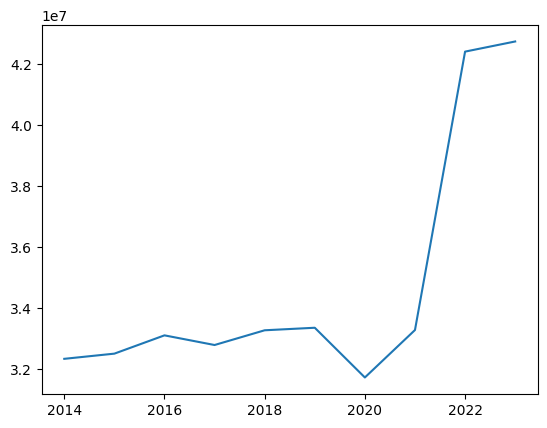

In [28]:
#first attempt at a line plot
plt.plot(demogr_df['YEAR'], demogr_df['WHT10'])

The Data set above shows that there was a huge jump in employment numbers from 2022-2023. This is due to the EEOC eleminating type 6 reporting. In order to account for this chamge in historical analysis, I'll switch to using proportions of the workforce instead of totals. 

(0.0, 100.0)

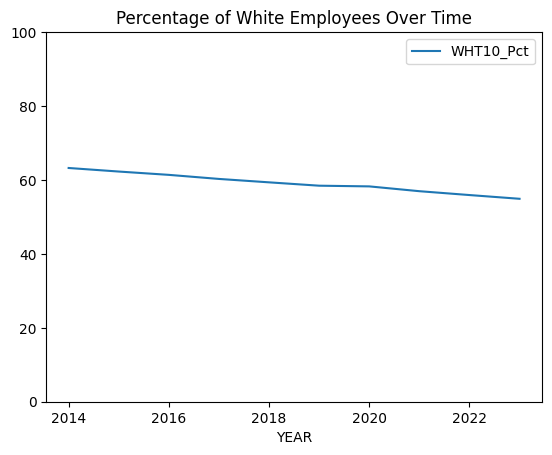

In [29]:
#Using 'TOTAL10' as the columns total workforce, I will create a new column to show the percentage of workers. 
demogr_df['WHT10_Pct'] = (demogr_df['WHT10'] / demogr_df['TOTAL10']) * 100

# Now plot the percentage over time
demogr_df.plot(
    x='YEAR', 
    y='WHT10_Pct', 
    kind='line', 
    title='Percentage of White Employees Over Time',
)
plt.ylim(0, 100) # Sets the Y-axis to scale from 0% to 100%


(0.0, 100.0)

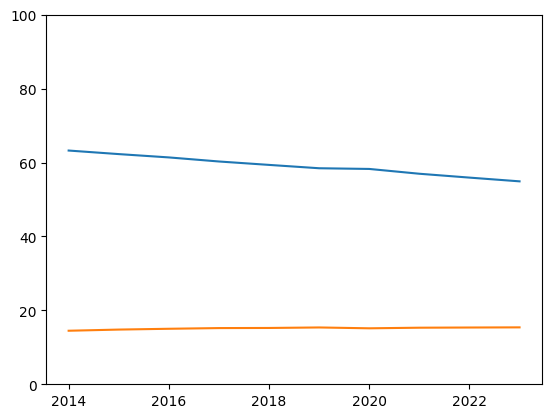

In [30]:
plt.plot(demogr_df['YEAR'], demogr_df['WHT10_Pct'], label='White')
plt.plot(demogr_df['YEAR'], demogr_df['BLKT10_Pct'], label='Black')
plt.ylim(0, 100)


In [31]:
cbsa_df.head()

,YEAR,NATION,REGION,DIVISION,STATE,CBSA,COUNTY,NAICS2,NAICS2_NAME,NAICS3,...,AIANM1_2_Pct,NHOPIM1_2_Pct,TOMRM1_2_Pct,WHF1_2_Pct,BLKF1_2_Pct,HISPF1_2_Pct,ASIANF1_2_Pct,AIANF1_2_Pct,NHOPIF1_2_Pct,TOMRF1_2_Pct
0,2014,United States,NaN,NaN,NaN,"Allentown-Bethlehem-Easton, PA-NJ",NaN,23.0,Construction,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,United States,NaN,NaN,NaN,"Allentown-Bethlehem-Easton, PA-NJ",NaN,31.0,Manufacturing,NaN,...,NaN,NaN,NaN,6.368243,0.270270,0.337838,0.405405,NaN,NaN,NaN
2,2014,United States,NaN,NaN,NaN,"Allentown-Bethlehem-Easton, PA-NJ",NaN,32.0,Manufacturing,NaN,...,NaN,NaN,NaN,NaN,0.067666,0.086999,0.164331,NaN,NaN,NaN
3,2014,United States,NaN,NaN,NaN,"Allentown-Bethlehem-Easton, PA-NJ",NaN,33.0,Manufacturing,NaN,...,NaN,NaN,NaN,NaN,0.035002,0.105005,0.084004,NaN,NaN,NaN
4,2014,United States,NaN,NaN,NaN,"Allentown-Bethlehem-Easton, PA-NJ",NaN,42.0,Wholesale Trade,NaN,...,NaN,NaN,NaN,4.829020,0.184843,0.069316,NaN,NaN,NaN,NaN


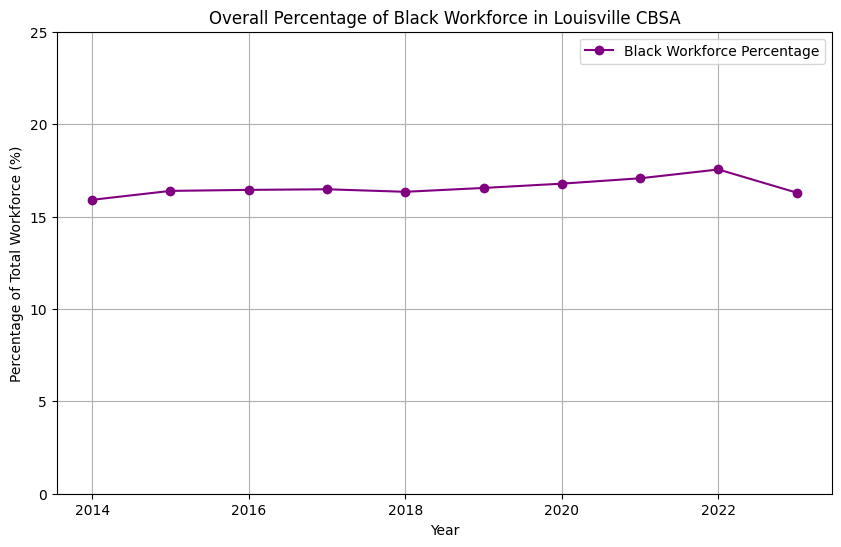

In [32]:
import matplotlib.pyplot as plt

# 1. Filter for Louisville just like before
louisville_df = cbsa_df[cbsa_df['CBSA'].str.contains('Louisville', case=False, na=False)].copy()

# 2. THE FIX: Group by 'YEAR' and sum up the raw counts across all industries
louisville_grouped = louisville_df.groupby('YEAR')[['TOTAL10', 'BLKT10']].sum().reset_index()

# 3. Recalculate the percentage using those new grand totals
louisville_grouped['BLKT10_Pct'] = (louisville_grouped['BLKT10'] / louisville_grouped['TOTAL10']) * 100

# 4. Build the graph using the new, grouped dataframe
plt.figure(figsize=(10, 6))

# Notice we are using 'louisville_grouped' here instead of 'louisville_df'
plt.plot(louisville_grouped['YEAR'], louisville_grouped['BLKT10_Pct'], marker='o', color='purple', label='Black Workforce Percentage')

# Add titles and labels
plt.title('Overall Percentage of Black Workforce in Louisville CBSA')
plt.xlabel('Year')
plt.ylabel('Percentage of Total Workforce (%)')

# Adjust the Y-axis based on the new aggregated data (e.g., 0 to 25)
plt.ylim(0, 25) 
plt.legend()
plt.grid(True)


plt.show()

Below I'm going to play around with Heatmaps to see if anything stands out.

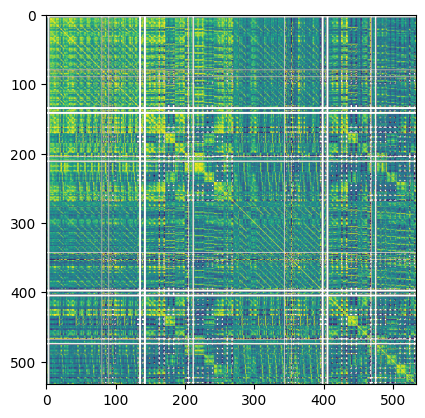

In [33]:
numeric_Louisville_df = louisville_df.select_dtypes(include= [np.number])
corr = numeric_Louisville_df.corr()
plt.imshow(corr)


In [34]:
d= dtale.show(numeric_Louisville_df)
d.open_browser()

In [36]:
"""
I need make my DF smaller, I want to only keep my Percent columns (PCT). 
I need to drop all of the numeric columns preceding "WHT10_Pct"
"""

df = numeric_Louisville_df
WHT10_Pct = list(df.columns).index('WHT10_Pct')
print(WHT10_Pct)

270


In [37]:
#Find the column index of the first column I need to drop
df = numeric_Louisville_df
Total10 = list(df.columns).index('TOTAL10')
print(Total10)

6


In [43]:
#Drop columns 6-269
num_pct_Louisville_df = df.drop(df.columns[6:270], axis=1)
d= dtale.show(num_pct_Louisville_df)
d.open_browser()

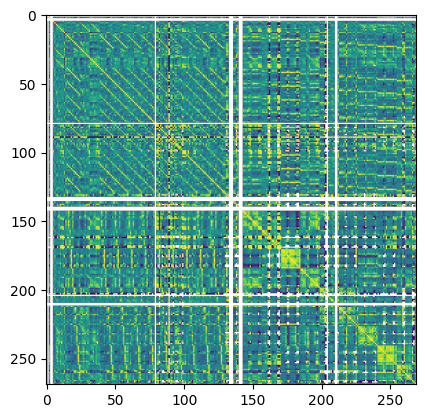

In [40]:
corr = num_pct_Louisville_df.corr()
plt.imshow(corr)

In [44]:
#I need to drop the index column from the df
df = numeric_Louisville_df
Index = list(df.columns).index('index')
print(Index)

ValueError: list.index(x): x not in list